# EDA: анализ приведенных данных

## Импорты, чтение и метанастройки

In [134]:
import re

import folium
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

DATA_DIR = "../data"
MAPS_DIR = "../maps"

train = pd.read_parquet(f"{DATA_DIR}/train.parquet")
queries = pd.read_parquet(f"{DATA_DIR}/benchmark_queries.parquet")
items = pd.read_parquet(f"{DATA_DIR}/benchmark_items.parquet")

print("train:", train.shape)
print("benchmark_queries:", queries.shape)
print("benchmark_items:", items.shape)

train: (497673, 19)
benchmark_queries: (2452, 6)
benchmark_items: (189212, 14)


## train поближе

`train.parquet` - 497673 строки, 19 колонок (search_* и item_*).

In [135]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 497673 entries, 0 to 497672
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   search_query               497673 non-null  str    
 1   search_location_id         497673 non-null  int64  
 2   search_is_delivery_search  497673 non-null  int32  
 3   search_infm_params_text    497673 non-null  str    
 4   search_category            497673 non-null  int64  
 5   item_title_raw             497673 non-null  str    
 6   item_rating_reviews_count  478462 non-null  float64
 7   item_rating                469441 non-null  float64
 8   item_price                 497673 non-null  object 
 9   item_microcat_id           497673 non-null  int64  
 10  item_longitude             497669 non-null  object 
 11  item_location_id           497673 non-null  int64  
 12  item_latitude              497669 non-null  object 
 13  item_is_phone_hidden       497673 non-nu

In [136]:
for col in ["item_price", "item_latitude", "item_longitude"]:
    train[col] = train[col].astype(float)

In [137]:
SEARCH_COLS = [col for col in train.columns if col.startswith("search_")]
SEARCH_COLS

['search_query',
 'search_location_id',
 'search_is_delivery_search',
 'search_infm_params_text',
 'search_category']

In [138]:
item = [col for col in train.columns if col.startswith("item")]
item

['item_title_raw',
 'item_rating_reviews_count',
 'item_rating',
 'item_price',
 'item_microcat_id',
 'item_longitude',
 'item_location_id',
 'item_latitude',
 'item_is_phone_hidden',
 'item_is_message_forbidden',
 'item_infm_params_text',
 'item_id',
 'item_description_raw',
 'item_category_id']

In [139]:
train.head()

,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
0,скупка телевизоров,652430,0,,114,Скупка б/у техники,91.00,4.99,1.00,2303374,39.71,652430,54.63,True,False,Вид услуги Место оказания услуг Первомайский п...,e8b685dffe1a408e,Скупаю практически любую современную новую и б...,114
1,автоподбор,640860,0,Рейтинг пользователя 4 звезды и выше,114,Автоподбор Разовый осмотр автомобиля,462.00,4.98,"3,500.00",2303374,44.05,640860,56.27,False,False,Вид услуги Место оказания услуг Нижний Новгоро...,92e1b0446f827b59,🚗 Автоподбор и выездная диагностика автомобиля...,114
2,баня на дровах,653240,0,"Онлайн-запись Тип услуги СПА-услуги, массаж Ви...",114,"Баня на дровах ""Прованс"" на Цветочной",NaN,NaN,"1,600.00",86469,30.13,653240,59.78,False,False,"Вид услуги Красота, здоровье Место оказания ус...",624846856ce81d69,В ритме современной жизни так сложно найти мо...,114
3,изготовление госномера на авто,634670,0,"Вид услуги Оборудование, производство",114,"Изготовление дубликатов авто номеров, гос номеров",14.00,4.71,"1,700.00",2303428,40.54,633570,45.42,False,False,"Вид услуги Оборудование, производство Тип услу...",45b8628b9c6e7b85,Изготовим дубликат номера по утере или износу ...,114
4,укладка плитки,658430,0,Тип услуги Ремонт квартир и домов под ключ Вид...,114,Ремонт и отделка квартир под ключ,1.00,5.00,"1,000.00",44725,69.50,658430,56.11,False,False,Вид услуги Ремонт и отделка Тип услуги Ремонт ...,c95a4a7daf2a967f,отделочные работы любой сложности.,114


### Пропуски

In [140]:
def missing_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    miss = df.isna().sum()
    rep = pd.DataFrame({"dtype": df.dtypes, "missing": miss, "missing_%": (miss / len(df) * 100).round(2)})
    print(name)
    return rep

display(missing_report(train, "train"))
display(missing_report(queries, "benchmark_queries"))
display(missing_report(items, "benchmark_items"))

train


,dtype,missing,missing_%
search_query,str,0,0.00
search_location_id,int64,0,0.00
search_is_delivery_search,int32,0,0.00
search_infm_params_text,str,0,0.00
search_category,int64,0,0.00
item_title_raw,str,0,0.00
item_rating_reviews_count,float64,19211,3.86
item_rating,float64,28232,5.67
item_price,float64,0,0.00
item_microcat_id,int64,0,0.00


benchmark_queries


,dtype,missing,missing_%
query_id,str,0,0.00
search_query,str,0,0.00
search_location_id,int64,0,0.00
search_is_delivery_search,int32,0,0.00
search_infm_params_text,str,0,0.00
search_category,int64,0,0.00


benchmark_items


,dtype,missing,missing_%
item_title_raw,str,0,0.00
item_rating_reviews_count,float64,11615,6.14
item_rating,float64,17631,9.32
item_price,object,0,0.00
item_microcat_id,int64,0,0.00
item_longitude,object,1,0.00
item_location_id,int64,0,0.00
item_latitude,object,1,0.00
item_is_phone_hidden,bool,0,0.00
item_is_message_forbidden,bool,0,0.00


**Инсайты:**
- Пропуски только в `item_rating`/`item_rating_reviews_count`(~6-9%) и единичные `item_latitude`/`item_longitude`.\
- Ключевые текстовые/категориальные поля без пропусков.

In [141]:
price = train["item_price"]

price.describe()

count           497,673.00
mean         19,711,227.10
std       3,827,553,571.50
min                  -1.00
25%                 400.00
50%               1,000.00
75%               2,000.00
max     999,999,999,999.00
Name: item_price, dtype: float64

In [142]:
(price <= 0).sum()

np.int64(37626)

In [143]:
(price == -1).sum()

np.int64(32631)

In [144]:
round((price == -1).sum() / len(train) * 100, 2)

np.float64(6.56)

In [145]:
round((price == 0.).sum() / len(train) * 100, 2)

np.float64(1.0)

In [146]:
(price > 1e7).sum()

np.int64(189)

In [147]:
sorted(price)[-200:]

[10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10101010.0,
 10175000.0,
 10500000.0,
 11111111.0,
 11111111.0,
 11111111.0,
 11111111.0,
 11111111.0,
 11111111.0,
 12000000.0,
 12094945.0,
 12222222.0,
 12295000.0,
 12388544.0,
 12800000.0,
 13000000.0,
 13900000.0,
 15000000.0,
 15000000.0,
 15000000.0,
 17820000.0,
 17820000.0,
 17820000.0,
 18650000.0,
 19000000.0,
 20000000.0,
 20000009.0,
 25000000.0,
 30000000.0,
 30000000.0,
 33333333.0,
 50000000.0,
 50000000.0,
 50000000.0,
 55555555.0,
 60000000.0,
 60000000.0,
 60000000.0,
 66666666.0,
 77777777.0,
 77777777.0,
 88888888.0,
 88888888.0,
 88888888.0,
 88888888.0,
 99999999.0,
 99999999.0,
 99999999.0,
 99999999.0,
 99999999.0,
 99999999.0,
 99999999.0,
 99999999.0,
 99999999.0,
 99999999.0,
 99999999.0,
 99999999.0,
 99999999.0,
 99999999.0,
 100000000.0,
 100000000.0,
 100000000.0,
 100000000.0,
 100000000.0,
 100000000.0,
 10000

**Инсайт - `item_price` требует чистки:**
- **6.56%** записей имеют `item_price == -1` - вероятно, закодировано «цена не указана» - сам факт отсутствия может дать некоторый сигнал, следует добавить колонку `item_price_missing`
- **1%** бесплатных услуг
- Длинный хвост фейковых высоких цен. (Fun-fact: некоторые из них похожи на номера телефонов)
- Перед загонкой цены как фичи куда-нибудь клипать/логарифмировать верхний хвост, а не использовать сырое значение. Тем более не смотреть на `mean`/`std` - они не репрезентативны из-за выбросов.

## Бенчи поближе

In [148]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 189212 entries, 0 to 189211
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   item_title_raw             189212 non-null  str    
 1   item_rating_reviews_count  177597 non-null  float64
 2   item_rating                171581 non-null  float64
 3   item_price                 189212 non-null  object 
 4   item_microcat_id           189212 non-null  int64  
 5   item_longitude             189211 non-null  object 
 6   item_location_id           189212 non-null  int64  
 7   item_latitude              189211 non-null  object 
 8   item_is_phone_hidden       189212 non-null  bool   
 9   item_is_message_forbidden  189212 non-null  bool   
 10  item_infm_params_text      189212 non-null  str    
 11  item_id                    189212 non-null  str    
 12  item_description_raw       189177 non-null  str    
 13  item_category_id           189212 non-nu

In [149]:
for col in ["item_price", "item_latitude", "item_longitude"]:
    items[col] = items[col].astype(float)

In [150]:
price = items["item_price"]

price.describe()

count           189,212.00
mean         19,860,289.53
std       3,730,627,552.71
min                  -1.00
25%                 380.00
50%               1,000.00
75%               2,500.00
max     777,777,777,777.00
Name: item_price, dtype: float64

In [151]:
items.head()

,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
0,Ремонт/выкуп компьют. и ноутбуков с выездом на...,57.00,5.00,500.00,2097573,42.05,631060,44.23,False,False,Вид услуги Компьютерная помощь Место оказания ...,111eb8b979577d79,"Выезд на дом в любое время, вплоть до 23:00\n\...",114
1,Обучение ребенка чтению,7.00,5.00,900.00,86453,49.63,631870,58.63,False,False,"Вид услуги Обучение, курсы Место оказания услу...",75fc8e10f5a66fc4,"Дорогие родители и маленькие книголюбы! \n\nЯ,...",114
2,Афрокудри 5+,14.00,5.00,"1,000.00",86467,40.94,628500,56.99,True,False,"Вид услуги Красота, здоровье Место оказания ус...",3f6ae81704565b9c,ВНИМАНИЕ Укладка !!!! 🥳\n\nАФРОкудри отличный ...,114
3,Монтаж малых архитектурных форм,2.00,5.00,"5,000.00",2058739,37.58,637640,55.66,False,False,Вид услуги Строительство Место оказания услуг ...,0618dec37a59a21a,Оказываем все виды услуг по сборке и монтажу и...,114
4,Репетитор по истории 10 класс ЕГЭ,19.00,5.00,"1,500.00",86456,44.75,624850,48.79,False,False,"Вид услуги Обучение, курсы Место оказания услу...",13da2c81574677ed,🚀 Сдай ЕГЭ по истории на 80+ за 6 месяцев!\n\n...,114


In [152]:
(price <= 0).sum()

np.int64(16588)

In [153]:
(price == -1).sum()

np.int64(15248)

In [154]:
round((price == -1).sum() / len(items) * 100, 2)

np.float64(8.06)

In [155]:
round((price == 0.).sum() / len(items) * 100, 2)

np.float64(0.71)

In [156]:
(price > 1e7).sum()

np.int64(76)

In [157]:
sorted(price)[-100:]

[9950000.0,
 9999999.0,
 9999999.0,
 9999999.0,
 9999999.0,
 9999999.0,
 9999999.0,
 9999999.0,
 9999999.0,
 9999999.0,
 9999999.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10000000.0,
 10010000.0,
 10383000.0,
 11000000.0,
 11111111.0,
 11111111.0,
 11111111.0,
 11111111.0,
 11200000.0,
 11900000.0,
 12222222.0,
 12222222.0,
 12222222.0,
 12500000.0,
 12500000.0,
 12500000.0,
 13000000.0,
 13600000.0,
 13607000.0,
 15250000.0,
 15900000.0,
 17900000.0,
 18000000.0,
 18181818.0,
 18525000.0,
 19800000.0,
 19999999.0,
 20000000.0,
 22222222.0,
 23000000.0,
 25000000.0,
 25000000.0,
 25000000.0,
 25252525.0,
 30000000.0,
 30000000.0,
 30000000.0,
 35000000.0,
 50000000.0,
 50000000.0,
 50000000.0,
 55555555.0,
 60000000.0,
 77777777.0,
 90000000.0,
 91937800.0,
 95000000.0,
 99999999.0,
 99999999.0,
 100000000.0,
 100000000.0,
 105500000.0,
 111111111.0,
 123123123.0,
 1231

Все то же самое: чистим, юзаем флаги

## Мультирелевантность: сколько item_id реально стоит за одним запросом

`train.parquet` - это атомарные **сессии поиска** (user делает запрос и выбирает один item).\
 Группируем по полному контексту запроса (`search_*`) и смотрим, сколько РАЗНЫХ `item_id` выбирали в разных сессиях с одинаковым контекстом - это прокси для того, сколько объявлений реально релевантны одному запросу.

In [158]:
items_per_context = train.groupby(SEARCH_COLS)["item_id"].nunique()
rows_per_context = train.groupby(SEARCH_COLS).size()

print("уникальных контекстов запроса:", items_per_context.shape[0])
print("доля запросов, встретившихся только 1 раз:", round((rows_per_context == 1).mean(), 3))
print("доля запросов с >1 релевантными разными item_id:", round((items_per_context > 1).mean(), 3))

repeated_mask = rows_per_context > 1
print("среди ПОВТОРЯЮЩИХСЯ запросов доля с >1 разным item_id:",
      round((items_per_context[repeated_mask] > 1).mean(), 4))

уникальных контекстов запроса: 354463
доля запросов, встретившихся только 1 раз: 0.836
доля запросов с >1 релевантными разными item_id: 0.15
среди ПОВТОРЯЮЩИХСЯ запросов доля с >1 разным item_id: 0.914


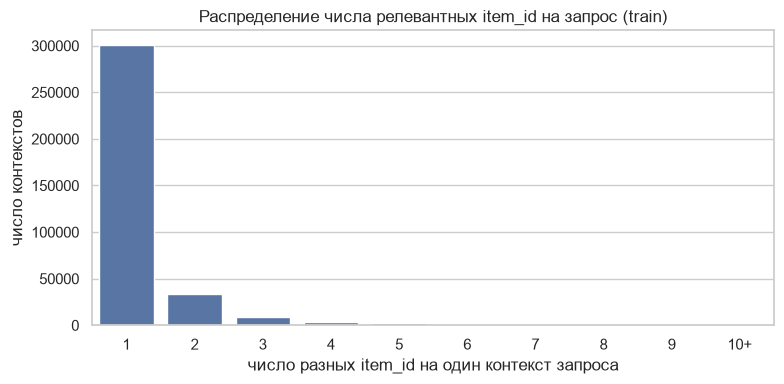

In [159]:
clipped = items_per_context.clip(upper=10)
dist = clipped.value_counts().sort_index()
labels = [str(i) if i < 10 else "10+" for i in dist.index]

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=labels, y=dist.values, ax=ax)
ax.set_xlabel("число разных item_id на один контекст запроса")
ax.set_ylabel("число контекстов")
ax.set_title("Распределение числа релевантных item_id на запрос (train)")
plt.tight_layout()
plt.show()

**Инсайт - мультирелевантность подтверждена и это не редкость:**
- **354463** уникальных полных контекста запроса; **84%** встретились только один раз (1 релевантный item).
- Но среди контекстов, повторившихся в разных сессиях, у **~91%** выбирались РАЗНЫЕ айтемы - то есть множественная релевантность не шум, а реальное свойство: разные пользователи закрывают один и тот же запрос разными, но одинаково подходящими объявлениями.
- нужно закрыть кандидатами весь релевантный набор, а не поймать один правдоподобный вариант.

## Категория и подкатегория как сигнал для фильтрации

Проверим: если жёстко фильтровать условием `item_category_id == search_category`, какую долю релевантных объявлений мы потеряем? Каждая строка train — это уже релевантная пара,
так что достаточно посмотреть долю совпадений напрямую.

In [160]:
cat_match = train["search_category"] == train["item_category_id"]
print("метча запроса-айтема на релевантных парах:", round(cat_match.mean(), 4))
print("несовпадений:", (~cat_match).sum(), "из", len(train))

метча запроса-айтема на релевантных парах: 0.9999
несовпадений: 53 из 497673


In [161]:
train["item_category_id"].value_counts()

item_category_id
114    497658
27          4
40          2
81          2
19          2
28          2
112         2
10          1
Name: count, dtype: int64

In [162]:
train["search_category"].value_counts()

search_category
114    497635
0          34
81          2
10          2
Name: count, dtype: int64

**Инсайт - `item_category_id` бесполезен как какой-то уникальный дискриминирующий сигнал. Как и указано в задании, делаем ретрив только на УСЛУГАХ:**
- Совпадений `search_category == item_category_id` - **~100%** (всего 53 исключения из 497673, в основном когда `search_category == 0` - вероятно, это «категория не выбрана»).
- Фильтрация по `item_category_id` бесполезна - не отсеет ничего из корпуса 189k объявлений.
- **Реальный сигнал - подкатегория `item_microcat_id`**, но прямого поля с "нужной микрокатегорией" на стороне запроса НЕТ - есть только `search_category` и `search_infm_params_text`.\
Значит, микрокатегорию для фильтрации нужно доставать текстовым матчингом/классификатором по `search_query`+`search_infm_params_text`.

In [163]:
print("уникальных подкатегорий в train (будучи релевантными):", train["item_microcat_id"].nunique())
print("уникальных подкатегорий в benchmark_items (весь бенч):", items["item_microcat_id"].nunique())

train_microcats = set(train["item_microcat_id"].unique())
bench_microcats = set(items["item_microcat_id"].unique())
only_in_bench = bench_microcats - train_microcats

print("подкатегорий, которых НЕТ среди релевантных в train:", len(only_in_bench))

unseen_items = items[items["item_microcat_id"].isin(only_in_bench)]
print(f"НО объявлений в бенче с 'незнакомой' подкатегорией: {len(unseen_items)} "
      f"({len(unseen_items) / len(items) * 100:.1f}% от всего бенча)")

уникальных подкатегорий в train (будучи релевантными): 212
уникальных подкатегорий в benchmark_items (весь бенч): 752
подкатегорий, которых НЕТ среди релевантных в train: 546
НО объявлений в бенче с 'незнакомой' подкатегорией: 1758 (0.9% от всего бенча)


**Инсайт:** в train всего 212 подкатегорий встречались, а в бенче их 752 - из них 546 вообще ни разу не были релевантными в train. Это мелкий хвост по объёму (**<1%** объявлений корпуса), но для этих объявлений чисто "запомнить частоты" не сработает - нужен обобщающий сигнал, способноть, а не сырая память с трейна

## Лексическое пересечение: запрос <=> заголовок + описание

Для скольких релевантных пар в query и в тексте объявления есть хотя бы одно общее слово?\
Это грубая верхняя граница recall для чистого точного match/BM25 подхода без морфологии и без семантики: если общих слов нет вообще ни в title, ни в description — такую пару лексика гарантированно не найдёт => нужна семантика (эмбеды, lm)

In [164]:
TOKEN_RE = re.compile(r"[а-яё0-9]+", re.IGNORECASE)
STOP_WORDS = {"и", "в", "на", "с", "для", "по", "от", "до", "или", "без", "не", "из", "за", "к", "у", "о", "об"}


def tokenize(text: str) -> set[str]:
    if not isinstance(text, str):
        return set()
    toks = TOKEN_RE.findall(text.lower())
    return {t for t in toks if len(t) >= 2 and t not in STOP_WORDS}


q_tok = train["search_query"].apply(tokenize)
title_tok = train["item_title_raw"].apply(tokenize)
desc_tok = train["item_description_raw"].apply(tokenize)

overlap_title = [len(q & t) > 0 for q, t in zip(q_tok, title_tok)]
overlap_desc = [len(q & d) > 0 for q, d in zip(q_tok, desc_tok)]
overlap_either = [a or b for a, b in zip(overlap_title, overlap_desc)]

n = len(train)
print("доля пар с общим словом query <=> title", round(sum(overlap_title) / n, 3))
print("доля пар с общим словом query <=> description:", round(sum(overlap_desc) / n, 3))
print("доля пар с общим словом query <=> (title ИЛИ desc):", round(sum(overlap_either) / n, 3))
print(f"пар БЕЗ общих слов вообще: {n - sum(overlap_either)} ({(n - sum(overlap_either)) / n * 100:.2f}%)")

доля пар с общим словом query <=> title 0.709
доля пар с общим словом query <=> description: 0.767
доля пар с общим словом query <=> (title ИЛИ desc): 0.882
пар БЕЗ общих слов вообще: 58838 (11.82%)


In [165]:
train_ov = train.assign(overlap_either=overlap_either)
examples = train_ov.loc[~train_ov["overlap_either"], ["search_query", "item_title_raw"]].head()
examples

,search_query,item_title_raw
4,укладка плитки,Ремонт и отделка квартир под ключ
6,наращивание ногтей,Мастер маникюр и педикюра
14,отделка помещений,Отделочные работы под ключ
25,художник,"Печать, картина, портрет по фото на холсте на ..."
38,газель,Сильные грузчики. Грузоперевозки. Газели


**Находка - 11.82% релевантных пар не имеют ни одного общего слова ни в title, ни в description.**

Но это верхняя граница ущерба, не факт: часть случаев - не отсутствие семантической связи, а чисто **проблема словоформ** (не делали ни стемминг, ни лемматизацию), например: пары про отделку или газель. Разные словоформы одного корня => простой стеммер/pymorphy2 это пары бы уже сметчил.

А есть и честно семантические случаи без общих корней: ногтевой сервис и пара с художником.

**Вывод**: лемматизация/стемминг в BM25-слое обязательны, а семантику найдут эмбеды

## Длины текстов

Запросы короткие (2/3 - медианы в трейне/бенче соответственно), заголовки объявлений тоже короткие (медиана = 4), а вот описания длинные (медиана ~130 слов, max=1568) - значит, для BM25/эмбеддингов description нельзя просто взять целиком, разумно учитывать длину при взвешивании (BM25 делает) либо обрезать/саммари при построении dense-представлений.

In [166]:
def word_count(s) -> int:
    return len(str(s).split())


length_stats = {
    "train.search_query": train["search_query"].apply(word_count),
    "train.item_title_raw": train["item_title_raw"].apply(word_count),
    "train.item_description_raw": train["item_description_raw"].apply(word_count),
    "benchmark_queries.search_query": queries["search_query"].apply(word_count),
    "benchmark_items.item_title_raw": items["item_title_raw"].apply(word_count),
    "benchmark_items.item_description_raw": items["item_description_raw"].apply(word_count),
}

summary = pd.DataFrame({
    name: {"mean": s.mean(), "median": s.median(), "max": s.max()}
    for name, s in length_stats.items()
}).T
summary

,mean,median,max
train.search_query,2.34,2.00,17.00
train.item_title_raw,4.36,4.00,22.00
train.item_description_raw,175.88,127.00,"1,568.00"
benchmark_queries.search_query,3.20,3.00,10.00
benchmark_items.item_title_raw,4.47,4.00,20.00
benchmark_items.item_description_raw,193.44,147.00,"1,568.00"


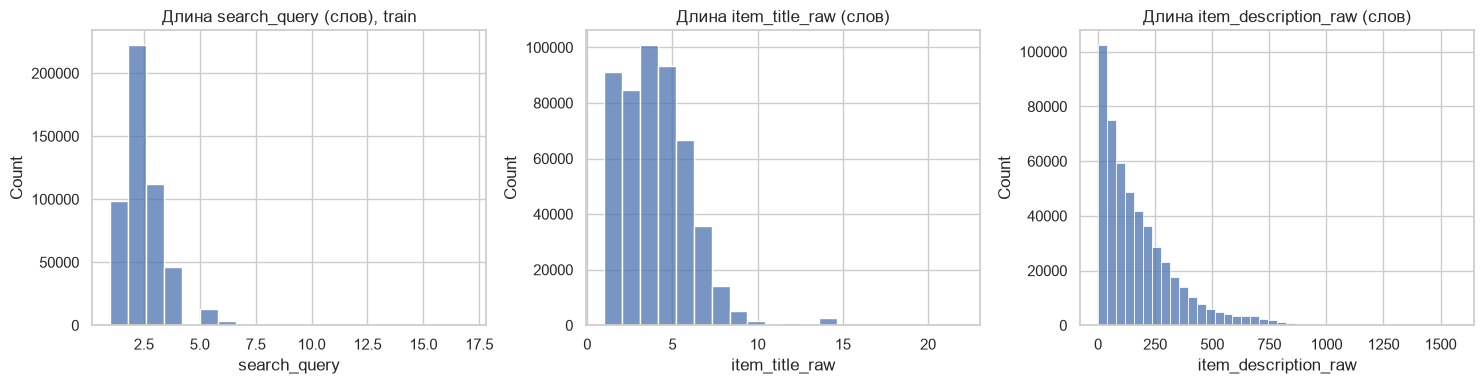

In [167]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(length_stats["train.search_query"], bins=20, ax=axes[0])
axes[0].set_title("Длина search_query (слов), train")
sns.histplot(length_stats["train.item_title_raw"], bins=20, ax=axes[1])
axes[1].set_title("Длина item_title_raw (слов)")
sns.histplot(length_stats["train.item_description_raw"], bins=40, ax=axes[2])
axes[2].set_title("Длина item_description_raw (слов)")
plt.tight_layout()
plt.show()

## Локация по специфике Авито (не география)

Насколько часто у релевантного объявления совпадает `item_location_id == search_location_id`?

In [168]:
loc_match = train["search_location_id"] == train["item_location_id"]
print("search_location_id == item_location_id на релевантных парах:", round(loc_match.mean(), 4))

search_location_id == item_location_id на релевантных парах: 0.831


**Инсайт:** совпадение локации - **83.1%**. В отличие от категории, локация НЕ годится как жёсткий фильтр (потеряем ~17% релевантных
объявлений - многие услуги все-таки являются "выездными"/без привязки к точному месту, это согласуется с наличием поля `search_is_delivery_search`).

Локацию стоит использовать как софт-сигнал/фичу для будущей стадии ранжирования (буст при совпадении, штраф за большое расстояние через `item_latitude`/`item_longitude`), а не как фильтр кандидатов.

In [169]:
top_loc = train["item_location_id"].value_counts().index[0]
sub = train[train["item_location_id"] == top_loc]

MOSCOW_LAT = (55.48, 56.05)
MOSCOW_LON = (36.75, 37.97)

in_moscow = sub["item_latitude"].between(*MOSCOW_LAT) & sub["item_longitude"].between(*MOSCOW_LON)

print("location_id:", top_loc)
print("доля координат внутри Москвы:", round(in_moscow.mean(), 4))
print("количество:", in_moscow.sum(), "из", len(sub))

location_id: 637640
доля координат внутри Москвы: 0.9996
количество: 44683 из 44701


Действительно, установили, что 637640 - **Москва**.\
Из моего уважения к геоданным, посмотрим на карты:

In [170]:
N = 1000
sample = (
    train.dropna(subset=["item_latitude", "item_longitude"])
    .drop_duplicates("item_id")
    .sample(N, random_state=42)
)

m = folium.Map(location=[55.75, 37.62], zoom_start=4)

for _, row in sample.iterrows():
    folium.CircleMarker(
        location=[row["item_latitude"], row["item_longitude"]],
        radius=1,
        fill=True,
        fill_opacity=0.5,
    ).add_to(m)

m.save(f"{MAPS_DIR}/russia.html")
m

In [171]:
import html


def sanitize(text, limit=None):
    text = str(text)
    if limit:
        text = text[:limit]
    text = text.replace("\\", "\\\\").replace("`", "\\`").replace("${", "\\${")
    return html.escape(text)

moscow = (
    train[train["item_location_id"] == 637640]
    .dropna(subset=["item_latitude", "item_longitude"])
    .drop_duplicates("item_id")
)

N = min(200, len(moscow))
sample = moscow.sample(N, random_state=42)

m = folium.Map(location=[55.75, 37.62], zoom_start=10)

for _, row in sample.iterrows():
    title = sanitize(row["item_title_raw"])
    description = sanitize(row["item_description_raw"], limit=100)
    tooltip_html = f"<b>{title}</b><br>{description}"
    folium.CircleMarker(
        location=[row["item_latitude"], row["item_longitude"]],
        radius=1,
        color="red",
        fill=True,
        fill_opacity=0.5,
        tooltip=tooltip_html,
    ).add_to(m)

m.save(f"{MAPS_DIR}/moscow.html")
m

## Рейтинг/цена: трейн vs бенч

Смотрим, отличается ли профиль релевантных объявлений (train) от всего корпуса (benchmark_items) по рейтингу и цене — если да, это потенциальный сигнал для ре-ранкера (например, "буст за высокий рейтинг"), если нет — сильного сигнала тут нет.

In [172]:
cols = ["item_rating", "item_rating_reviews_count"]
comparison = pd.DataFrame({
    "train": train[cols].mean(),
    "bench": items[cols].mean(),
})
comparison["train_median"] = train[cols].median()
comparison["bench_median"] = items[cols].median()
comparison

,train,bench,train_median,bench_median
item_rating,4.82,4.79,5.00,5.00
item_rating_reviews_count,88.59,66.48,25.00,18.00


**Инсайт:** `item_rating` почти не отличается - слабый сигнал. А вот `item_rating_reviews_count` отличается заметнее (train mean\~88.6 / median=25 vs корпус mean\~66.5 / median=18) - выбираемые релевантные объявления в среднем заметно более "отревьюены", чем случайные объявления бенча.\
Значит, **число отзывов - более полезная фича для реранкера, чем сам рейтинг** (популярность важнее среднего балла, который у всех и так около 5).

## Насколько бенчмарк похож на train

Train - это лог по категории 114 («Услуги»).\
Посмотрим, действительно ли `benchmark_items` - та же генеральная совокупность, или там есть значимая примесь других категорий, и пересекаются ли тексты запросов.

In [173]:
print("доля item_category_id==114 в train:", round((train["item_category_id"] == 114).mean(), 3))
print("доля item_category_id==114 в benchmark_items:", round((items["item_category_id"] == 114).mean(), 3))
print("уникальных item_category_id: train =", train["item_category_id"].nunique(),
      ", benchmark_items =", items["item_category_id"].nunique())
print()

train_q_norm = train["search_query"].str.lower().str.strip()
bench_q_norm = queries["search_query"].str.lower().str.strip()
overlap_q = set(train_q_norm) & set(bench_q_norm)
print("уникальных текстов запроса: train =", train_q_norm.nunique(), ", benchmark_queries =", bench_q_norm.nunique())
print(f"точное текстовое совпадение запроса с train: {len(overlap_q)} из {bench_q_norm.nunique()} "
      f"({len(overlap_q) / bench_q_norm.nunique() * 100:.1f}%)")

доля item_category_id==114 в train: 1.0
доля item_category_id==114 в benchmark_items: 0.99
уникальных item_category_id: train = 8 , benchmark_items = 47

уникальных текстов запроса: train = 74529 , benchmark_queries = 2452
точное текстовое совпадение запроса с train: 907 из 2452 (37.0%)


**Инсайты:**
- Train полностью из услуг, бенч на 99%. То есть бенч чуть шире, чем то, на чём тренировалась интуиция по train — жёстко резать по `item_category_id != 114` рискованно, лучше не фильтровать по этому полю вовсе (в случае реранкинга на топ50).
- **37%** текстов запросов из `benchmark_queries` дословно встречались в train (запрос совпадает посимвольно). Это круто: для трети бенчмарка можно напрямую посмотреть исторические выборы по почти такому же запросу как сильный сигнал/фичу, для остальных 63% нужно обобщение по тексту/категории/эмбеддингам.

## Итоговое summary: что это значит для архитектуры решения

- Recall@50 требует закрывать весь набор релевантных item, а не один лучший - мультирелевантность подтверждена эмпирически
- `item_category_id` бесполезен как фильтр - почти все и так в одной категории (114)
- `item_microcat_id` - реальный сигнал, но у запроса нет прямого поля под него
- `search_location_id` - мягкий сигнал, не жёсткий фильтр.
- Чистая лексика покрывает только ~88% релевантных пар - нужен ещё семантический слой
- `item_price` требует чистки
- `item_rating_reviews_count` - более полезная фича, чем `item_rating`